# Modeling Event Bias Contributors with Generalized Linear Model

The goal of this notebook is to develop a model that helps determine which meteorological variables can explain systematic precipitation biases across several instruments using a generalized linear model.


In [1]:
import os
os.chdir('/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/')

# general
import glob
import datetime as dt
from pathlib import Path

# data 
import xarray as xr 
import numpy as np
import pandas as pd

# plotting
import matplotlib.pyplot as plt
import plotly.express as px 
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# Configure Plotly for Jupyter notebooks
pio.renderers.default = "notebook"
# Alternative renderers you can try if "notebook" doesn't work:
# pio.renderers.default = "plotly_mimetype+notebook"
# pio.renderers.default = "jupyter_lab"

# helper tools
from metpy import calc, units
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from pygam import LinearGAM, s, f, GammaGAM, l, te, PoissonGAM
from collections import OrderedDict 
from utils import pygam_test_dataset

In [2]:
def get_file_destination(DATA_DIR, SRC, PRODUCT, WITH_MET, RAW_OR_NORMALIZED):
    if WITH_MET and RAW_OR_NORMALIZED == "raw":
        WITH_MET = "_with_raw_met"
    elif WITH_MET and RAW_OR_NORMALIZED == "normalized":
        WITH_MET = "_with_normalized_met"
    else:
        WITH_MET = ""

    if PRODUCT == "gridded":
        PRODUCT_NAME = "_gridded"
        FOLDER_NAME = "gridded_events"
    elif PRODUCT == "events":
        PRODUCT_NAME = ""
        FOLDER_NAME = "events"
    else:
        PRODUCT_NAME = ""
    if SRC in ['asfs', 'sos']:
        SITE = 'kettle_ponds'
    elif SRC in ['bb', 'sail']:
        SITE = 'gothic'
    else:
        SITE = input("Enter site name (gothic or kettle_ponds): ")
    return DATA_DIR / SITE / f"{FOLDER_NAME}{WITH_MET}" / f"{SITE}{PRODUCT_NAME}_precipitation_event_comparisons_{SRC}{WITH_MET}.nc"

# Prepare dataset for model attempt

In [3]:
# need to get the dataset in order with variables I want and the bias value
DATA_DIR = '/storage/dlhogan/precipitation-rodeo/data/for_analysis'
# Define your root and sites
DATA_DIR = Path(DATA_DIR)
STORAGE_DIR = '/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/events'
SRC = "sail" # one of [bb, sail, asfs, sos, '']
PRODUCT = "events" # or events
WITH_MET = True  # or True
RAW_OR_NORMALIZED = "raw"  # or raw
file_dest = get_file_destination(DATA_DIR, SRC, PRODUCT, WITH_MET, RAW_OR_NORMALIZED)
print(f"Loading data from: {file_dest}")

ds = xr.open_dataset(file_dest).sel(benchmark='billy_barr_precip')

Loading data from: /storage/dlhogan/precipitation-rodeo/data/for_analysis/gothic/events_with_raw_met/gothic_precipitation_event_comparisons_sail_with_raw_met.nc


In [9]:
if SRC == 'sail':
    site = 'gothic'
else:
    site = 'kettle_ponds'
# get data for qc
qc_ds = xr.open_dataset(f"/storage/dlhogan/precipitation-rodeo/data/processed/final/{site}_precipitation_30min.nc")
qc_vars = [var for var in qc_ds.data_vars if 'qc' in var]
qc_ds = qc_ds[qc_vars]

In [115]:
instrument = 'sail_org'
example_ds = ds.sel(test_instrument=instrument)
event_bad_qc_list = []
event_missing_qc_list = []
for e in example_ds.event_id.values:
    event_bad_qc = qc_ds.sel(time=slice(example_ds.sel(event_id=e).start_time.values, example_ds.sel(event_id=e).end_time.values))[f'qc_bad_{instrument}'].sum()
    event_missing_qc = qc_ds.sel(time=slice(example_ds.sel(event_id=e).start_time.values, example_ds.sel(event_id=e).end_time.values))[f'qc_missing_{instrument}'].sum()
    event_bad_qc_list.append(event_bad_qc.values)
    event_missing_qc_list.append(event_missing_qc.values)
# add as variable
example_ds['bad_qc_count'] = (('event_id'), event_bad_qc_list)
example_ds['missing_qc_count'] = (('event_id'), event_missing_qc_list)

# if values are na, make missing qc count 1
example_ds['missing_qc_count'] = example_ds['missing_qc_count'].where(~example_ds['wind_speed_max'].isnull(),1)

# drop events with any nans
example_ds = example_ds.dropna(dim='event_id')

In [132]:
y = example_ds['diff'].values
X = np.vstack([
    example_ds['wind_speed_max'].values, # 0 maximum wind speed during event, non-linear relationship expected, likely threshold behavior
    # example_ds['max_diff'].values, # 1 maximum difference in precipitation rate (benchmark minus test gauge) over the event
    example_ds['pressure_min'].values, # 2 minimum pressure during event, non-linear relationship expected
    example_ds['wind_speed_mean'].values, # 3 mean wind speed during event, non-linear relationship expected but could be linear
    (example_ds['temperature_max'] - example_ds['temperature_min']).values, # 6 temperature range during event
    # example_ds['temperature_max'].values, # 4 maximum temperature during event
    # example_ds['bad_qc_count'].values, # 5 count of bad qc during event
    # example_ds['missing_qc_count'].values, # 6 count of missing qc during event
    # example_ds['temperature_min'].values, # 5 minimum temperature during event
    # example_ds['temperature_mean'].values, # 7 perhaps related northerly/southerly flow? warm air from the south
    # example_ds['v_wind_mean'].values, # 8 mean v-component of wind during event, perhaps related to mean temperature
    # example_ds['u_wind_mean'].values, # 9 mean v-component of wind during event, perhaps related to mean temperature
])

X = X.T
y = y

print(X.shape, y.shape)


(134, 4) (134,)


In [135]:
s_terms = s(0, n_splines=10) + s(1, n_splines=10) + s(2, n_splines=10) + s(3) #+ s(4) + s(5) + s(6) + s(7) + s(8) + s(9)
gam = LinearGAM(terms=s_terms).fit(X,y)


In [136]:
grid_search_gam = LinearGAM(terms=s_terms).gridsearch(X,y, lam=[np.logspace(-3, 5, 3)]*len(s_terms))

  0% (0 of 81) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  2% (2 of 81) |                         | Elapsed Time: 0:00:00 ETA:   0:00:02


  4% (4 of 81) |#                        | Elapsed Time: 0:00:00 ETA:   0:00:02
  7% (6 of 81) |#                        | Elapsed Time: 0:00:00 ETA:   0:00:02
  9% (8 of 81) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:02
 12% (10 of 81) |##                      | Elapsed Time: 0:00:00 ETA:   0:00:02
 14% (12 of 81) |###                     | Elapsed Time: 0:00:00 ETA:   0:00:02
 17% (14 of 81) |####                    | Elapsed Time: 0:00:00 ETA:   0:00:02
 19% (16 of 81) |####                    | Elapsed Time: 0:00:00 ETA:   0:00:01
 22% (18 of 81) |#####                   | Elapsed Time: 0:00:00 ETA:   0:00:01
 24% (20 of 81) |#####                   | Elapsed Time: 0:00:00 ETA:   0:00:01
 27% (22 of 81) |######                  | Elapsed Time: 0:00:00 ETA:   0:00:01
 28% (23 of 81) |######                  | Elapsed Time: 0:00:00 ETA:   0:00:01
 30% (25 of 81) |#######                 | Elapsed Time: 0:00:00 ETA:   0:00:01
 33% (27 of 81) |########               

In [137]:
grid_search_gam.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      6.4236
Link Function:                     IdentityLink Log Likelihood:                                  -894.0618
Number of Samples:                          134 AIC:                                             1802.9709
                                                AICc:                                            1803.9669
                                                GCV:                                              344.2847
                                                Scale:                                            314.7102
                                                Pseudo R-Squared:                                   0.3024
Feature Function                  Lam

/tmp/ipykernel_3472663/2120320205.py:1: UserWarning:

KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 




In [138]:
import numpy as np

def gam_term_variance(gam, X):
    """
    Computes a simple, effective GAM feature importance score:
    the variance of each partial dependence function.
    """
    import numpy as np
    scores = []
    
    for i in range(len(gam.terms) - 1):
        XX = gam.generate_X_grid(term=i)
        pdep = gam.partial_dependence(term=i)
        pdep_centered = pdep - pdep.mean()
        scores.append(np.var(pdep_centered))
    norm_term_variances = scores / np.sum(scores)
    return norm_term_variances


def gam_term_energy(gam):
    energies = []
    for i in range(gam.n_terms):
        pdep = gam.partial_dependence(term=i)
        pdep_centered = pdep - pdep.mean()
        energies.append(np.sum(pdep_centered**2))
    return np.array(energies)

def permutation_importance_gam(gam, X, y, metric):
    baseline = metric(y, gam.predict(X))
    importances = []

    for i in range(X.shape[1]):
        X_perm = X.copy()
        np.random.shuffle(X_perm[:, i])
        permuted_score = metric(y, gam.predict(X_perm))
        importances.append(permuted_score - baseline)

    return np.array(importances)

term_variances = gam_term_variance(grid_search_gam, X)
print("GAM Term Variances:", term_variances)


GAM Term Variances: [3.07713629e-04 8.84455766e-01 1.13982336e-01 1.25418431e-03]


In [139]:
import matplotlib.pyplot as plt
import numpy as np
import math

def plot_gam_terms_with_importance(gam, feature_names=None, ncols=2, figsize=(14, 10)):
    """
    Create a multi-panel figure showing:
      - partial dependence smooths (with CI bands)
      - arranged in a side-by-side grid with shared y-limits
      - feature importance bar plot (variance of partial dependence)
    """

    n_terms = len(gam.terms) - 1  # exclude intercept

    # --- Compute partial dependence for each term ---
    XX_list = []
    pdep_list = []
    confi_list = []
    importances = []   # variance-based feature importance

    for i in range(n_terms):
        XX = gam.generate_X_grid(term=i)
        pdep, confi = gam.partial_dependence(term=i, width=0.95)

        # center curves
        offset = pdep.mean()
        pdep_centered = pdep - offset
        confi_centered = confi - offset

        # variance = importance
        importances.append(np.var(pdep_centered))

        XX_list.append(XX[:, i])
        pdep_list.append(pdep_centered)
        confi_list.append(confi_centered)

    importances = gam_term_variance(grid_search_gam, X)

    # --- Determine global y-limits for consistency ---
    all_vals = np.concatenate([
        np.concatenate([c[:,0], c[:,1], p])
        for c, p in zip(confi_list, pdep_list)
    ])
    y_min, y_max = all_vals.min(), all_vals.max()

    # --- Figure layout: smooth terms + bottom bar plot ---
    nrows = math.ceil(n_terms / ncols) + 2  # bottom row = bar plot
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(nrows, ncols, height_ratios=[1]*(nrows-1) + [0.7])

    # --- Plot GAM smooth terms ---
    ax_idx = 0
    axes = []
    for i in range(n_terms):
        row = ax_idx // ncols
        col = ax_idx % ncols
        ax = fig.add_subplot(gs[row, col])
        axes.append(ax)

        XX = XX_list[i]
        pdep = pdep_list[i]
        confi = confi_list[i]

        ax.plot(XX, pdep, lw=2)
        ax.fill_between(XX, confi[:,0], confi[:,1], alpha=0.25)

        name = feature_names[i] if feature_names else f"Feature {i}"
        ax.set_title(name, fontsize=12)
        ax.axhline(0, color="gray", linestyle="--", lw=1)
        ax.set_ylim(y_min, y_max)

        ax_idx += 1

    # fill empty subplots (if any)
    while ax_idx < (nrows - 1) * ncols:
        fig.add_subplot(gs[ax_idx // ncols, ax_idx % ncols]).axis("off")
        ax_idx += 1

    # --- Bottom Feature Importance Bar Plot ---
    ax_imp = fig.add_subplot(gs[-2:, :])
    x = np.arange(n_terms)
    ax_imp.bar(x, importances)

    ax_imp.set_xticks(x)
    ax_imp.set_xticklabels(
        feature_names if feature_names else [f"X{i}" for i in range(n_terms)],
        rotation=45,
        ha="right"
    )
    ax_imp.set_ylabel("Feature Importance (Variance of Partial Dependence)")
    ax_imp.set_title("GAM Feature Importance")

    plt.tight_layout()
    return


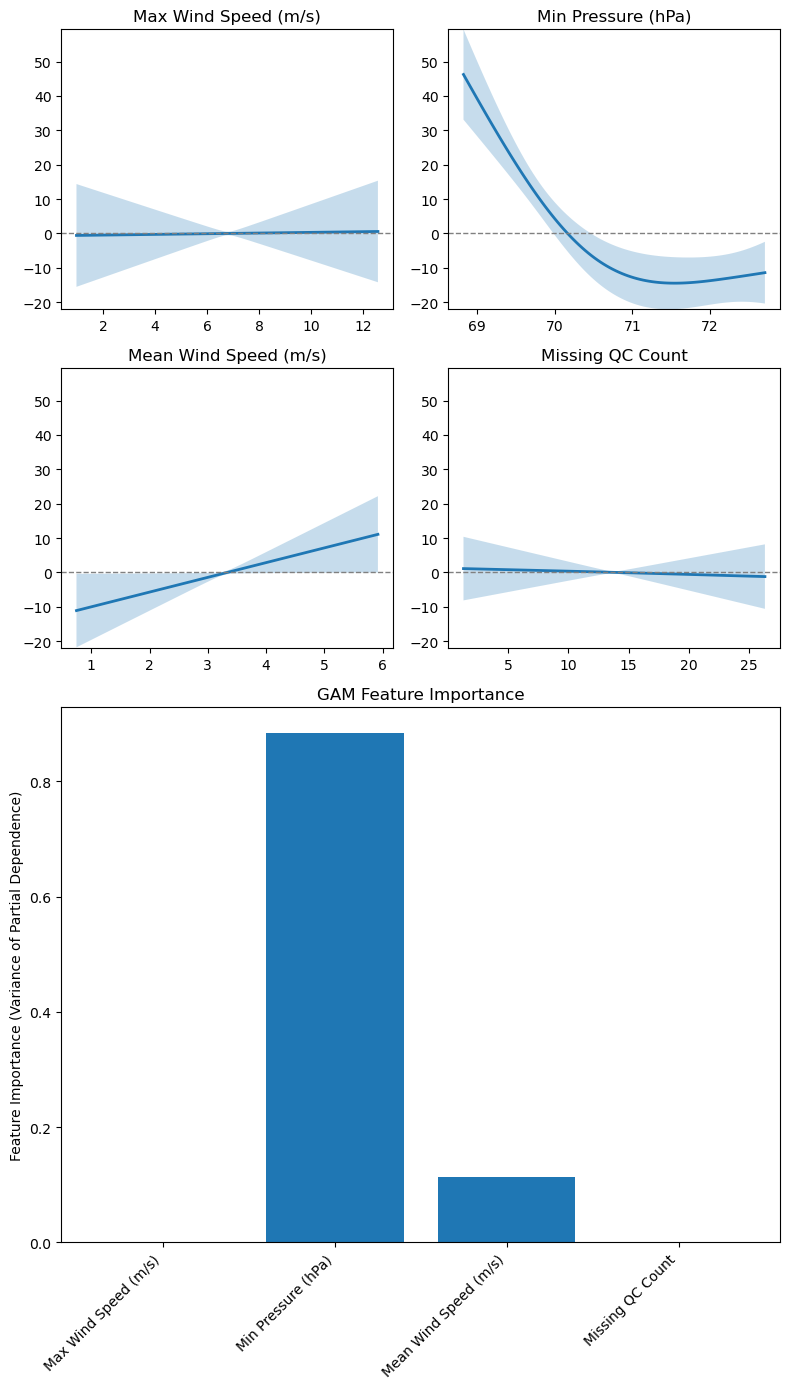

In [140]:
plot_gam_terms_with_importance(grid_search_gam, feature_names=[
    'Max Wind Speed (m/s)',
    # 'Max Difference in\nPrecipitation Rate (mm/hr)',
    'Min Pressure (hPa)',
    'Mean Wind Speed (m/s)',
    # 'Temperature Range (°C)',
    # 'Max Temperature (°C)',
    # 'Bad QC Count',
    'Missing QC Count',
    # 'Min Temperature (°C)',
    # 'Mean Temperature (°C)',
    # 'Mean V-Wind (m/s)',
    # 'Mean U-Wind (m/s)',
], figsize=(8, 14))